In [ ]:
# Install if needed
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [ ]:
# For file upload
from google.colab import files
# Upload multiple files (CSV/JSON)
uploaded = files.upload()

# Check uploaded filenames
print("Uploaded files:", uploaded.keys())

Saving dim_match_summary.csv to dim_match_summary (1).csv
Saving dim_players.csv to dim_players (1).csv
Saving dim_players_no_images.csv to dim_players_no_images (1).csv
Saving fact_bating_summary.csv to fact_bating_summary (1).csv
Saving fact_bowling_summary.csv to fact_bowling_summary (1).csv
Uploaded files: dict_keys(['dim_match_summary (1).csv', 'dim_players (1).csv', 'dim_players_no_images (1).csv', 'fact_bating_summary (1).csv', 'fact_bowling_summary (1).csv'])


In [ ]:
# For file upload
from google.colab import files
# Upload multiple files (CSV/JSON)
uploaded = files.upload()

# Check uploaded filenames
print("Uploaded files:", uploaded.keys())

Saving t20_wc_batting_summary.json to t20_wc_batting_summary (1).json
Saving t20_wc_bowling_summary.json to t20_wc_bowling_summary (1).json
Saving t20_wc_match_results.json to t20_wc_match_results (1).json
Saving t20_wc_player_info.json to t20_wc_player_info (1).json
Uploaded files: dict_keys(['t20_wc_batting_summary (1).json', 't20_wc_bowling_summary (1).json', 't20_wc_match_results (1).json', 't20_wc_player_info (1).json'])


In [ ]:
# CSV files
matches = pd.read_csv("dim_match_summary.csv")
batting = pd.read_csv("fact_bating_summary.csv")
bowling = pd.read_csv("fact_bowling_summary.csv")

# JSON files
with open("t20_wc_match_results.json") as f:
    match_results = pd.json_normalize(json.load(f)[0]['matchSummary'])

with open("t20_wc_batting_summary.json") as f:
    batting_json = pd.json_normalize(json.load(f)[0]['battingSummary'])

with open("t20_wc_bowling_summary.json") as f:
    bowling_json = pd.json_normalize(json.load(f)[0]['bowlingSummary'])

In [ ]:
# Quick look at data
print("Matches:\n", matches.head(), "\n")
print("Batting:\n", batting.head(), "\n")
print("Bowling:\n", bowling.head(), "\n")

# Summary statistics
print("Batting Summary:\n", batting.describe(include='all'))
print("Bowling Summary:\n", bowling.describe(include='all'))


Matches:
          team1        team2       winner     margin   ground     matchDate  \
0      Namibia    Sri Lanka      Namibia    55 runs  Geelong  Oct 16, 2022   
1  Netherlands       U.A.E.  Netherlands  3 wickets  Geelong  Oct 16, 2022   
2     Scotland  West Indies     Scotland    42 runs   Hobart  Oct 17, 2022   
3      Ireland     Zimbabwe     Zimbabwe    31 runs   Hobart  Oct 17, 2022   
4      Namibia  Netherlands  Netherlands  5 wickets  Geelong  Oct 18, 2022   

      match_id  
0  T20I # 1823  
1  T20I # 1825  
2  T20I # 1826  
3  T20I # 1828  
4  T20I # 1830   

Batting:
                   match teamInnings  battingPos             batsmanName  runs  \
0  Namibia Vs Sri Lanka     Namibia           1      Michael van Lingen     3   
1  Namibia Vs Sri Lanka     Namibia           2           Divan la Cock     9   
2  Namibia Vs Sri Lanka     Namibia           3  Jan Nicol Loftie-Eaton    20   
3  Namibia Vs Sri Lanka     Namibia           4           Stephan Baard    26   
4 

In [ ]:
print("Matches:\n", matches.head())
print("\nBatting:\n", batting.head())
print("\nBowling:\n", bowling.head())

print("\nBatting Info:")
print(batting.info())

print("\nBowling Info:")
print(bowling.info())

Matches:
          team1        team2       winner     margin   ground     matchDate  \
0      Namibia    Sri Lanka      Namibia    55 runs  Geelong  Oct 16, 2022   
1  Netherlands       U.A.E.  Netherlands  3 wickets  Geelong  Oct 16, 2022   
2     Scotland  West Indies     Scotland    42 runs   Hobart  Oct 17, 2022   
3      Ireland     Zimbabwe     Zimbabwe    31 runs   Hobart  Oct 17, 2022   
4      Namibia  Netherlands  Netherlands  5 wickets  Geelong  Oct 18, 2022   

      match_id  
0  T20I # 1823  
1  T20I # 1825  
2  T20I # 1826  
3  T20I # 1828  
4  T20I # 1830  

Batting:
                   match teamInnings  battingPos             batsmanName  runs  \
0  Namibia Vs Sri Lanka     Namibia           1      Michael van Lingen     3   
1  Namibia Vs Sri Lanka     Namibia           2           Divan la Cock     9   
2  Namibia Vs Sri Lanka     Namibia           3  Jan Nicol Loftie-Eaton    20   
3  Namibia Vs Sri Lanka     Namibia           4           Stephan Baard    26   
4  

In [ ]:
# Replace "-" with NaN
batting.replace("-", np.nan, inplace=True)
bowling.replace("-", np.nan, inplace=True)

# Convert numeric columns
batting['runs'] = pd.to_numeric(batting['runs'], errors='coerce').fillna(0)
batting['balls'] = pd.to_numeric(batting['balls'], errors='coerce').replace(0,1)

bowling['wickets'] = pd.to_numeric(bowling['wickets'], errors='coerce').fillna(0)
bowling['economy'] = pd.to_numeric(bowling['economy'], errors='coerce').fillna(0)

# Clean names
batting['batsmanName'] = batting['batsmanName'].str.strip().str.title()
bowling['bowlerName'] = bowling['bowlerName'].str.strip().str.title()

print("✅ Data cleaned")

✅ Data cleaned


In [ ]:
# Batting metrics
batting['strike_rate'] = (batting['runs'] / batting['balls']) * 100
batting['boundary_percent'] = ((batting['4s'] + batting['6s']) / batting['balls']) * 100

# Normalize features
batting['runs_norm'] = batting['runs'] / batting['runs'].max()
batting['sr_norm'] = batting['strike_rate'] / batting['strike_rate'].max()
batting['boundary_norm'] = batting['boundary_percent'] / batting['boundary_percent'].max()

# Final impact score
batting['impact_score'] = (
    batting['runs_norm'] * 0.4 +
    batting['sr_norm'] * 0.3 +
    batting['boundary_norm'] * 0.3
)

# Bowling score
bowling['impact_score'] = (bowling['wickets']*20) - (bowling['economy']*2)

print("✅ KPIs Created")

✅ KPIs Created


In [ ]:
batting_consistency = batting.groupby('batsmanName').apply(lambda x: (x['runs']>30).mean()*100)
bowling_consistency = bowling.groupby('bowlerName').apply(lambda x: (x['wickets']>=2).mean()*100)

print("✅ Consistency Calculated")

✅ Consistency Calculated


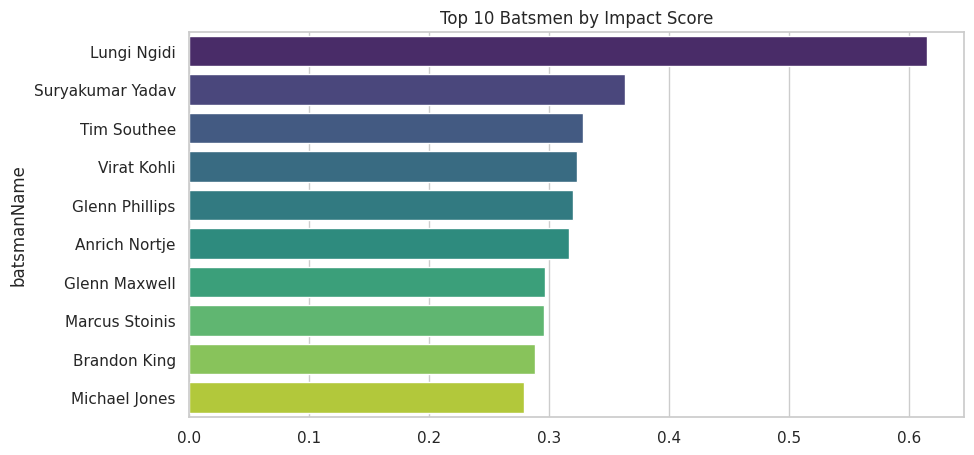

In [ ]:
top_batsmen = batting.groupby('batsmanName')['impact_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="viridis")
plt.title("Top 10 Batsmen by Impact Score")
plt.show()

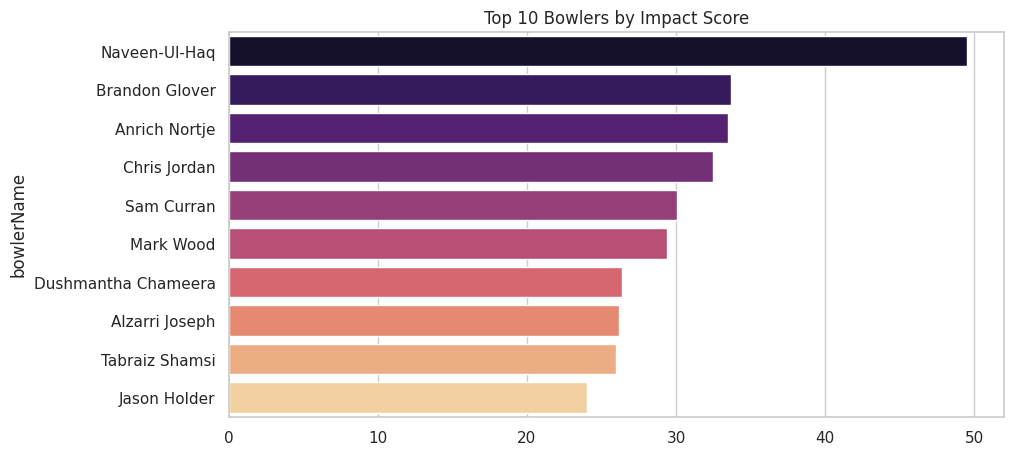

In [ ]:
top_bowlers = bowling.groupby('bowlerName')['impact_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="magma")
plt.title("Top 10 Bowlers by Impact Score")
plt.show()

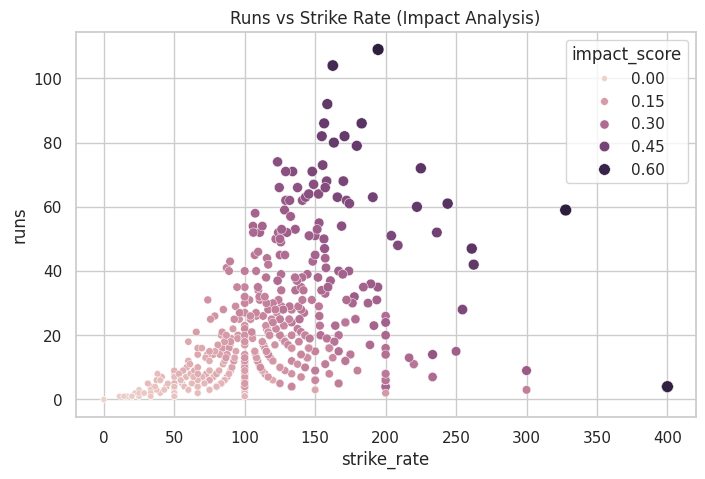

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=batting,
    x='strike_rate',
    y='runs',
    size='impact_score',
    hue='impact_score'
)
plt.title("Runs vs Strike Rate (Impact Analysis)")
plt.show()

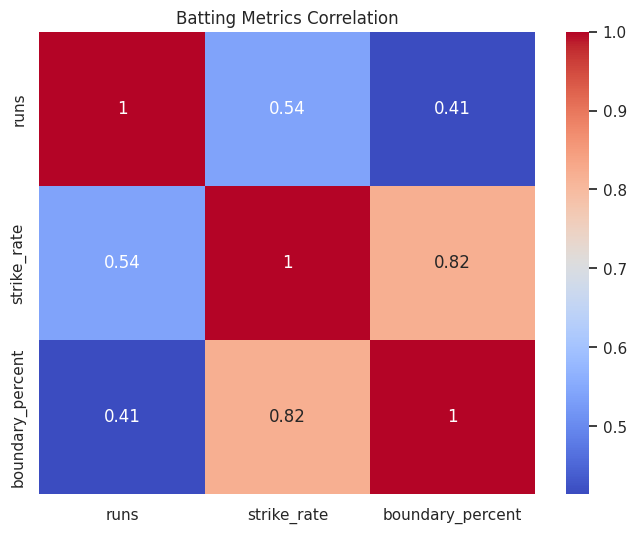

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    batting[['runs','strike_rate','boundary_percent']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Batting Metrics Correlation")
plt.show()

In [ ]:
def suggest_best_xi():
    top_bats = batting.groupby('batsmanName')['impact_score'].mean().sort_values(ascending=False).head(7)
    top_bowl = bowling.groupby('bowlerName')['impact_score'].mean().sort_values(ascending=False).head(4)

    return list(top_bats.index) + list(top_bowl.index)

print("🏏 Best XI:\n", suggest_best_xi())

🏏 Best XI:
 ['Lungi Ngidi', 'Suryakumar Yadav', 'Tim Southee', 'Virat Kohli', 'Glenn Phillips', 'Anrich Nortje', 'Glenn Maxwell', 'Naveen-Ul-Haq', 'Brandon Glover', 'Anrich Nortje', 'Chris Jordan']


In [ ]:
def suggest_captain():
    combined = pd.concat([batting_consistency, bowling_consistency]).sort_values(ascending=False)
    return combined.index[0]

print("⭐ Suggested Captain:", suggest_captain())

⭐ Suggested Captain: Naveen-Ul-Haq


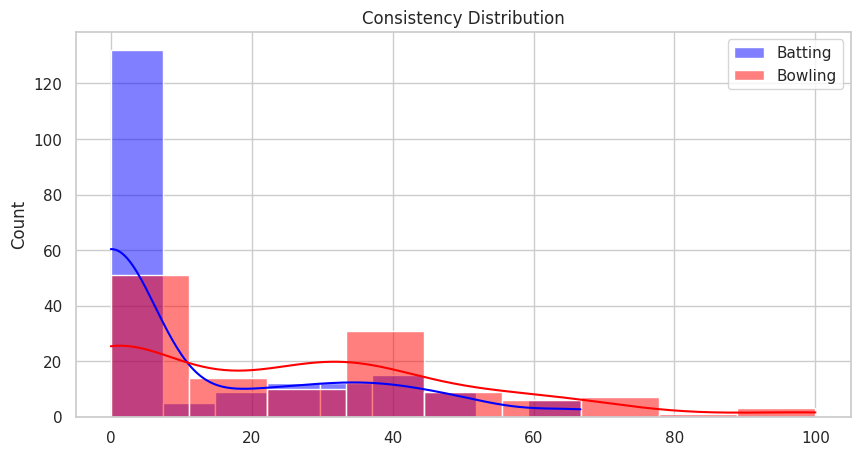

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(batting_consistency, color="blue", label="Batting", kde=True)
sns.histplot(bowling_consistency, color="red", label="Bowling", kde=True)

plt.legend()
plt.title("Consistency Distribution")
plt.show()

## 📊 Key Insights
- Players with high strike rate and boundary percentage dominate impact score
- Consistency is a strong indicator of leadership (captain selection)
- Balanced teams outperform high-scoring-only teams
- Multivariate analysis shows strike rate + runs together define performance